In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hydra import compose, initialize


# Load config

In [ ]:
with initialize(version_base=None, config_path="../conf"):
    config = compose(config_name="health_prediction_config")

# Read data

In [93]:
health_df = pd.read_csv(Path("..") / config.bronze_dataset_path)
health_df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0


# EDA

In [94]:
# Preview df and check the shape
health_df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0


In [95]:
# Data types
health_df.dtypes

Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol             object
Glucose                 object
Smoking                 object
Alcohol Consumption     object
Exercise                object
BMI                    float64
Family History          object
Heart Disease            int64
Diabetes                 int64
Stroke                   int64
Kidney Disease           int64
Cancer                   int64
Alzheimer's Disease      int64
COPD                     int64
Liver Disease            int64
Parkinson's Disease      int64
Tuberculosis             int64
dtype: object

In [96]:
# Check for null values
health_df.isna().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

In [97]:
# Check for duplcate rows
print(f"{health_df.duplicated().sum()} duplicated rows")

0 duplicated rows


## Numerical Columns

In [98]:
# Describe numerical columns
health_df[["Age", "BMI"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,52.881000,20.958915,18.000000,34.750000,52.500000,71.000000,89.000000
BMI,1000.0,29.213037,6.196368,18.504881,23.924004,28.892349,34.663806,39.974048


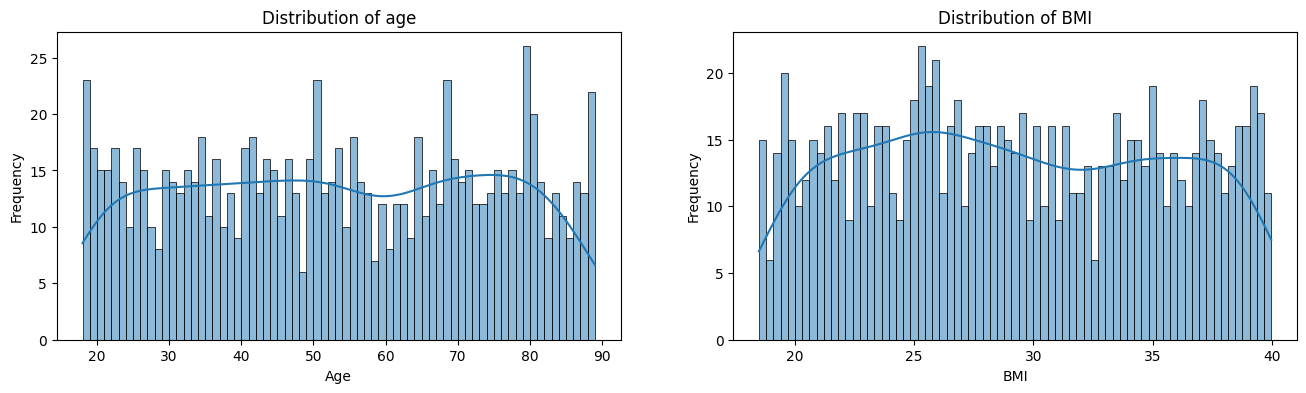

In [99]:
def df_range(df, row):
    return df[row].max() - df[row].min()


fig, axes = plt.subplots(1, 2, figsize=(16, 4))

age_range = df_range(health_df, "Age")
sns.histplot(data=health_df, x="Age", ax=axes[0], bins=age_range, kde=True)
axes[0].set_title("Distribution of age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

bmi_range = df_range(health_df, "BMI")
sns.histplot(data=health_df, x="BMI", ax=axes[1], bins=age_range, kde=True)
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Frequency")

plt.show()

## Categorical Columns

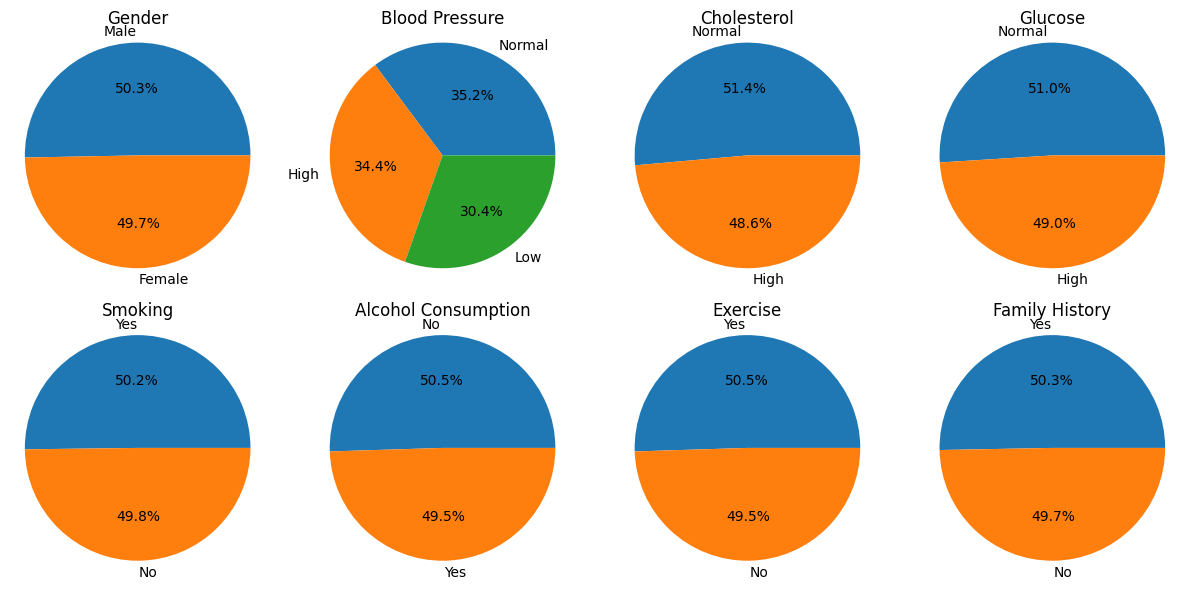

In [100]:
input_cat_cols = ["Gender", "Blood Pressure", "Cholesterol", "Glucose", "Smoking", "Alcohol Consumption", "Exercise", "Family History"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = np.array(axes).ravel()

for ax, col in zip(axes, input_cat_cols):
    counts = health_df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
    ax.set_title(col)
    ax.axis("equal")

for ax in axes[len(input_cat_cols) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()


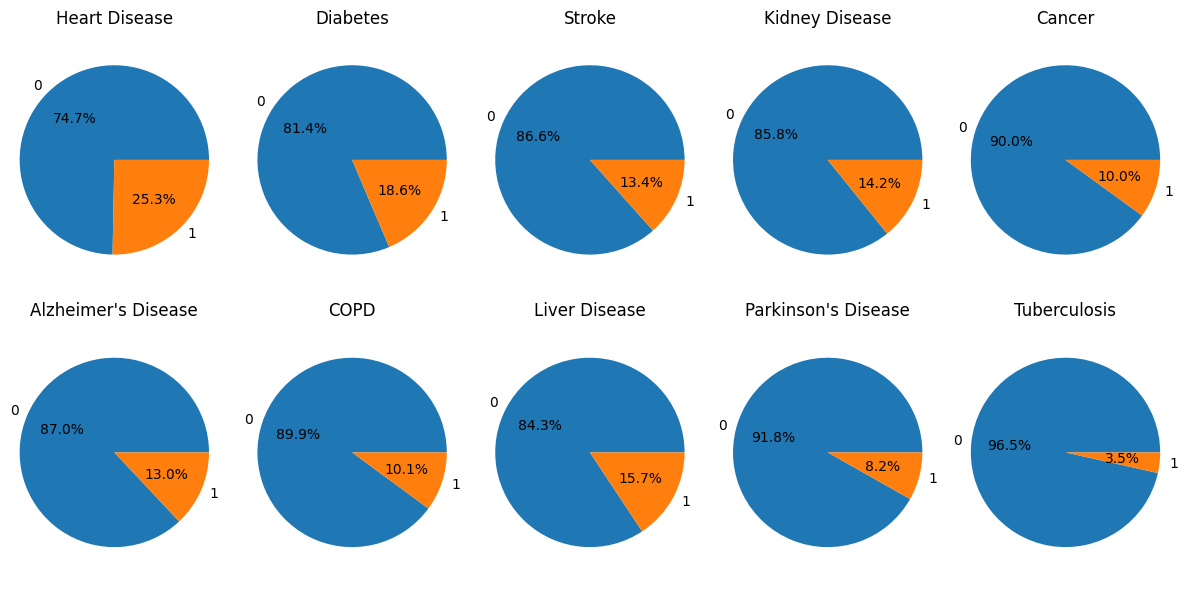

In [101]:
output_cat_cols = ["Heart Disease", "Diabetes", "Stroke", "Kidney Disease", "Cancer", "Alzheimer's Disease", "COPD", "Liver Disease", "Parkinson's Disease", "Tuberculosis"]

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = np.array(axes).ravel()

for ax, col in zip(axes, output_cat_cols):
    counts = health_df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
    ax.set_title(col)
    ax.axis("equal")

for ax in axes[len(output_cat_cols) :]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Multicollinearity

In [102]:
# Convert categorical columns to numerical

# Binary columns
health_df["Gender"] = health_df["Gender"].replace({"Male": 0, "Female": 1})

normal_high_cols = ["Cholesterol", "Glucose"]
health_df[normal_high_cols] = health_df[normal_high_cols].replace({"Normal": 0, "High": 1})

yes_no_cols = ["Smoking", "Alcohol Consumption", "Exercise", "Family History"]
health_df[yes_no_cols] = health_df[yes_no_cols].replace({"No": 0, "Yes": 1})

# One hot encoding
health_df = pd.get_dummies(health_df, columns=["Blood Pressure"], drop_first=True, dtype=int)

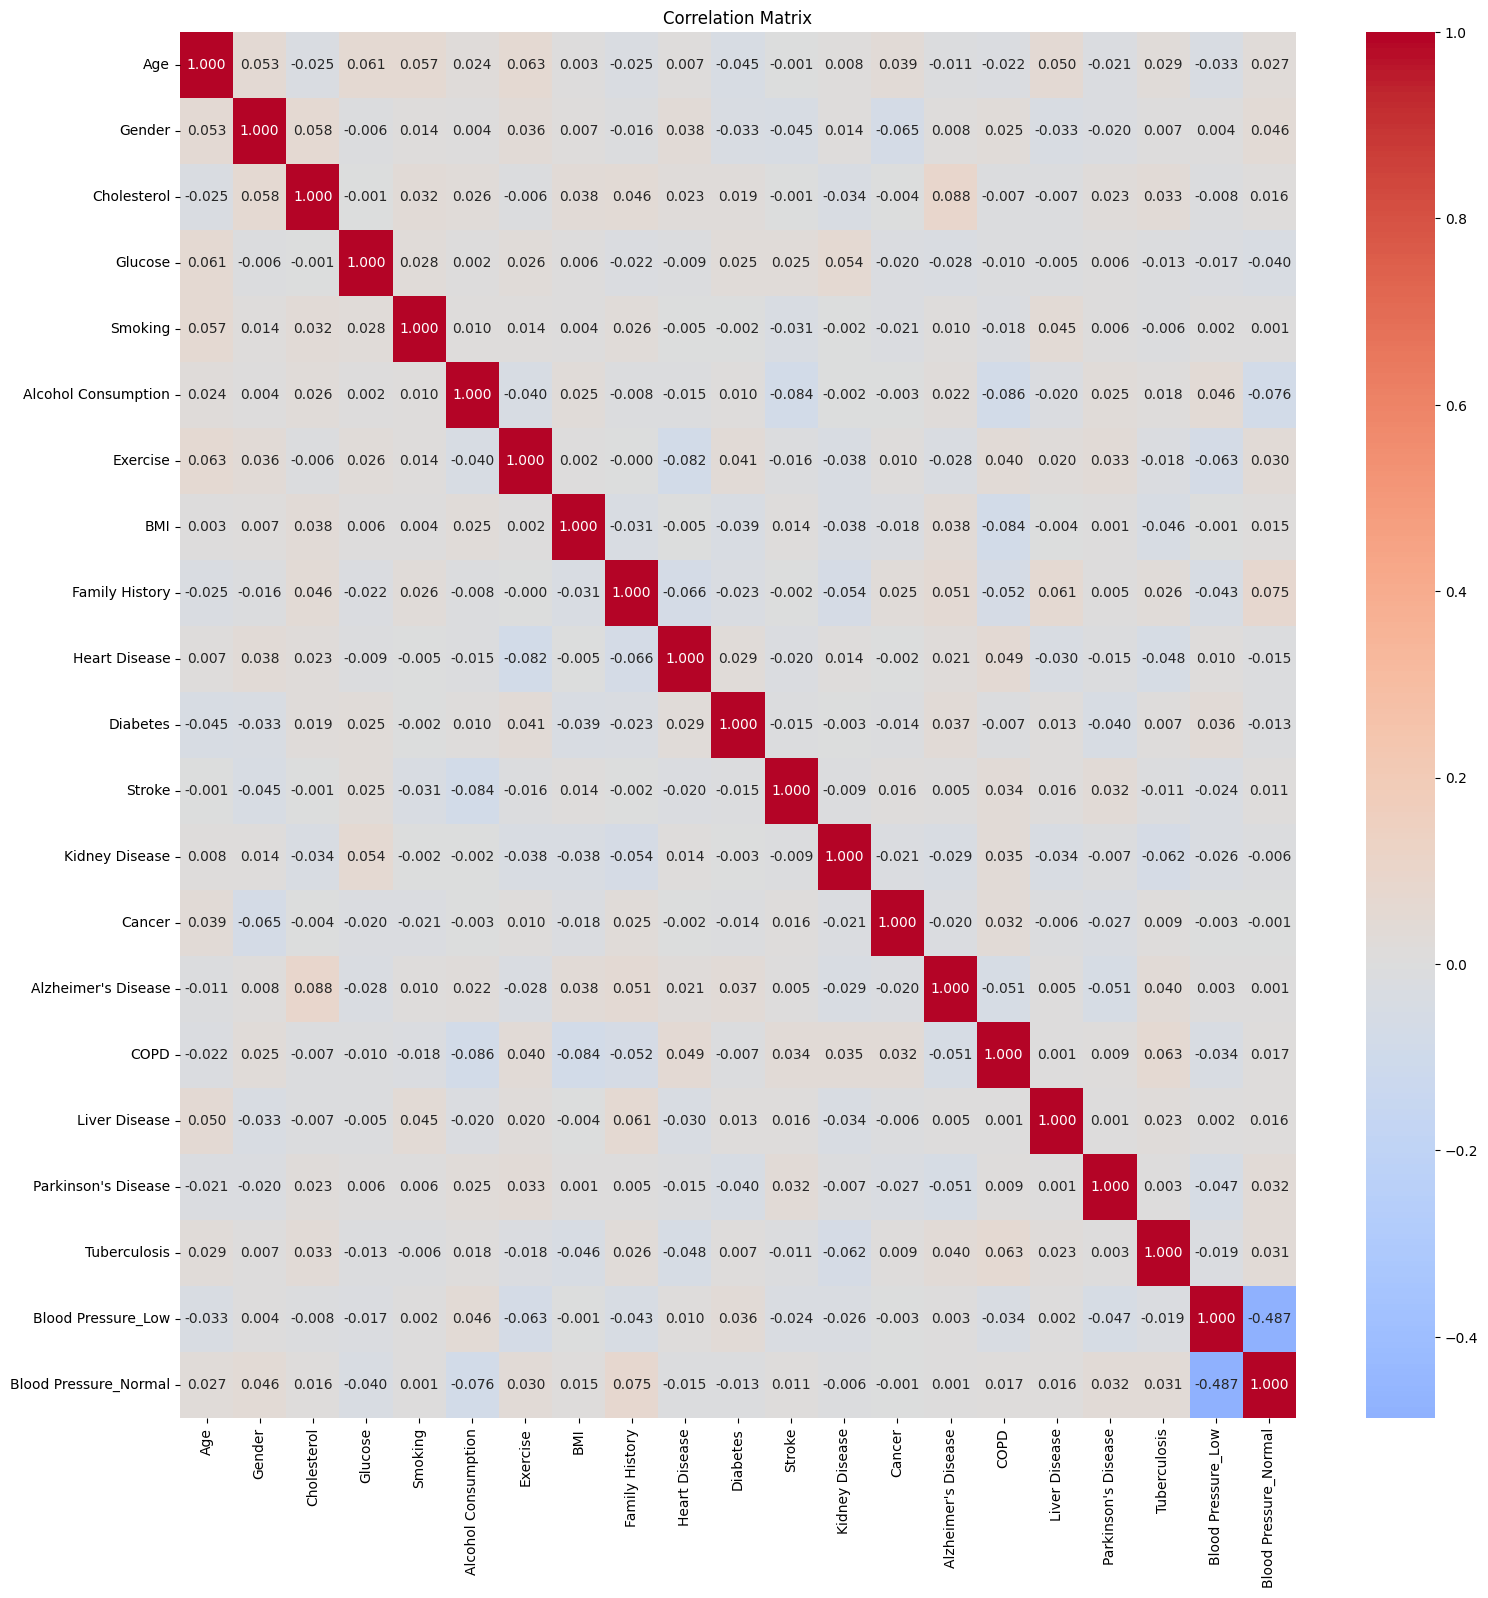

In [103]:
# Correlation matrix
corr = health_df.corr()

plt.figure(figsize=(18, 18))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [104]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

input_cols = [
    "Age",
    "Gender",
    "Cholesterol",
    "Glucose",
    "Smoking",
    "Alcohol Consumption",
    "Exercise",
    "BMI",
    "Family History",
    "Blood Pressure_Low",
    "Blood Pressure_Normal",
]

X = health_df[input_cols].astype(float)

vif_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, index) for index in range(X.shape[1])],
    }
)

vif_df.sort_values("VIF", ascending=False)

,Feature,VIF
7,BMI,9.553895
0,Age,6.375416
6,Exercise,1.999811
4,Smoking,1.990313
10,Blood Pressure_Normal,1.988196
1,Gender,1.982661
8,Family History,1.960259
5,Alcohol Consumption,1.959503
2,Cholesterol,1.937904
3,Glucose,1.937468


Given the high VIF of BMI and Age, consider training 2 sets of models, one with Age and BMI and one without.

## Save silver dataset

In [ ]:
health_df.to_csv(Path("..") / config.silver_dataset_path, lineterminator="\n", index=False)